*Kjersti Stangeland, September 2026*

In [31]:
from glob import glob
import cmocean.cm as cmo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.fft import fft, fftfreq

#%matplotlib widget

## Aim of notebook
* Look through the results Maxime got from the lab in the spring semester 2025.
* Get familiar with the data processing methods he did
* Check if his results are correct, are the wave parameters scaled correctly?
* Find out what would be interesting for me to look at further.

__Plan:__

* Make a program such that you can choose a water height, position of probes and a frequency and it will give you the results for all runs.

__Find out__:
- Which equation was used to figure out frequencies and amplitudes?
- What is the modified files?

In [32]:
water_height_folders = ['20 cm', '20 cm no plates', '30 cm', '30 cm no plates', '40 cm', '40 cm no plates']

# Choose a water height to work with
water_height = water_height_folders[0]
D = 0.2  # water depth [m]

In [33]:
# Defining some constants for later
H = 0.05  # height of plates [m]
D_H = D - H  # depth of porous layer

g = 9.81  # Gravity [m^2/s]
h = 0.00122  # Characteristic height [m]
nu = 10e-6  # Kinematic viscosity of water at 20 deg C [m^2/s]

In [34]:
# Path to files
basepath = glob('/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs')[0]
positions = ['P0', 'P1', 'P2', 'P3', 'P4']
runs = ['run1', 'run2', 'run3']

if water_height == water_height_folders[0] or water_height == water_height_folders[1]:
    # Frequencies for the given depth
    frequencies = ['f076', 'f092', 'f107', 'f122', 'f137', 'f153']
    amplitude = 'A015'

if water_height == water_height_folders[2] or water_height == water_height_folders[3]:
    # Frequencies for the given depth
    frequencies = ['f059', 'f071', 'f083', 'f095', 'f106', 'f118']
    amplitude = 'A030' 

if water_height == water_height_folders[4]:
    # Frequencies for the given depth
    frequencies = ['f050', 'f060', 'f070', 'f080', 'f090', 'f100']
    amplitude = 'A03'

if water_height == water_height_folders[5]:
    # Frequencies for the given depth
    frequencies = ['f1', 'f05', 'f06', 'f07', 'f08', 'f09']
    amplitude = 'A030'

In [35]:
# Choose a frequency to work with:
freq = frequencies[0]
f = 0.76  # [Hz] = [s^-1]

# Choose a rack position to work with:
pos = positions[1]

In [36]:
filepaths = []
for run in runs:
    filepath = f'{basepath}/{water_height}/' + pos + f'/{freq}/{freq}_{amplitude}_{pos}_{run}.csv'
    filepaths.append(filepath)

In [37]:
filepaths

['/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/20 cm/P1/f076/f076_A015_P1_run1.csv',
 '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/20 cm/P1/f076/f076_A015_P1_run2.csv',
 '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/20 cm/P1/f076/f076_A015_P1_run3.csv']

In [38]:
headers = ['time', 'p1', 'p2', 'p3', 'p4', 'speed of sound']

df_run1 = pd.read_csv(filepaths[0], header=None)
df_run2 = pd.read_csv(filepaths[1], header=None)
df_run3 = pd.read_csv(filepaths[2], header=None)

df_run1.columns = headers
df_run2.columns = headers
df_run3.columns = headers

The probes measure water level every 4th millisecond. Acquisition time is 30 seconds.

In [39]:
pd.to_datetime(df_run1.iloc[-1, 0]) - pd.to_datetime(df_run1.iloc[0, 0])

Timedelta('0 days 00:00:29.992000')

As we see, it takes some time for the waves to start. The first 1000-1500 data points are just noise from the probes. Therefore, to clean the data and only evaluate the signal from the passing waves we can subtract the mean of the first 200 data points. This is at least what Maxime did.

Text(0.5, 0.93, 'Raw data, \n Frequency: 0.76 Hz, Probe position: P1')

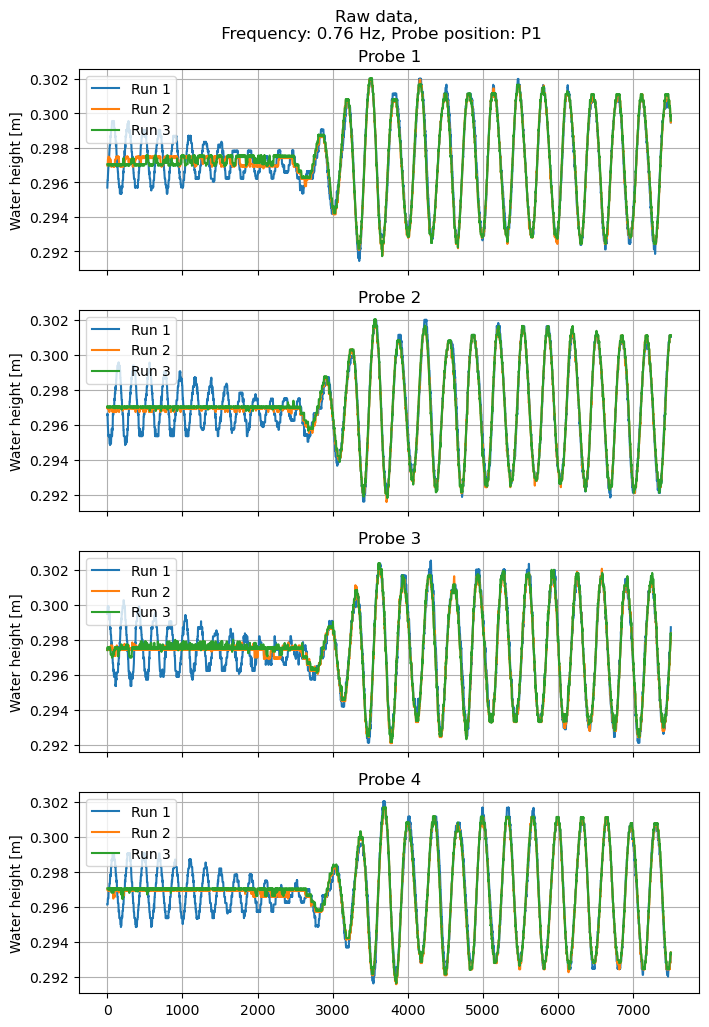

In [40]:
fig, ax = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

ax[0].plot(df_run1['p1'], label='Run 1')
ax[0].plot(df_run2['p1'], label='Run 2')
ax[0].plot(df_run3['p1'], label='Run 3')
ax[0].set_title('Probe 1')

ax[1].plot(df_run1['p2'], label='Run 1')
ax[1].plot(df_run2['p2'], label='Run 2')
ax[1].plot(df_run3['p2'], label='Run 3')
ax[1].set_title('Probe 2')

ax[2].plot(df_run1['p3'], label='Run 1')
ax[2].plot(df_run2['p3'], label='Run 2')
ax[2].plot(df_run3['p3'], label='Run 3')
ax[2].set_title('Probe 3')

ax[3].plot(df_run1['p4'], label='Run 1')
ax[3].plot(df_run2['p4'], label='Run 2')
ax[3].plot(df_run3['p4'], label='Run 3')
ax[3].set_title('Probe 4')

for axs in ax:
    axs.legend(loc='upper left')
    axs.grid()

    axs.set_ylabel('Water height [m]')

fig.suptitle(f'Raw data, \n Frequency: {f} Hz, Probe position: {pos}', y=0.93)

In [41]:
def modify(df):
    '''
    Removes noise from data by subtracting the mean of the first 200 rows,
    and converts timestamps to datetime values.
    '''
    # Removing noise
    for col in range(1, 5):
        noise = df.iloc[:200, col].mean()
        df.iloc[:, col] = df.iloc[:, col] - noise

    # Fixing the timestamps
    df['time'] = pd.to_datetime(df['time'])

    return df

In [42]:
run1 = modify(df_run1)
run2 = modify(df_run2)
run3 = modify(df_run3)

Text(0.5, 0.93, 'Cleaned data \n Frecuency: 0.76 Hz, Probe position: P1')

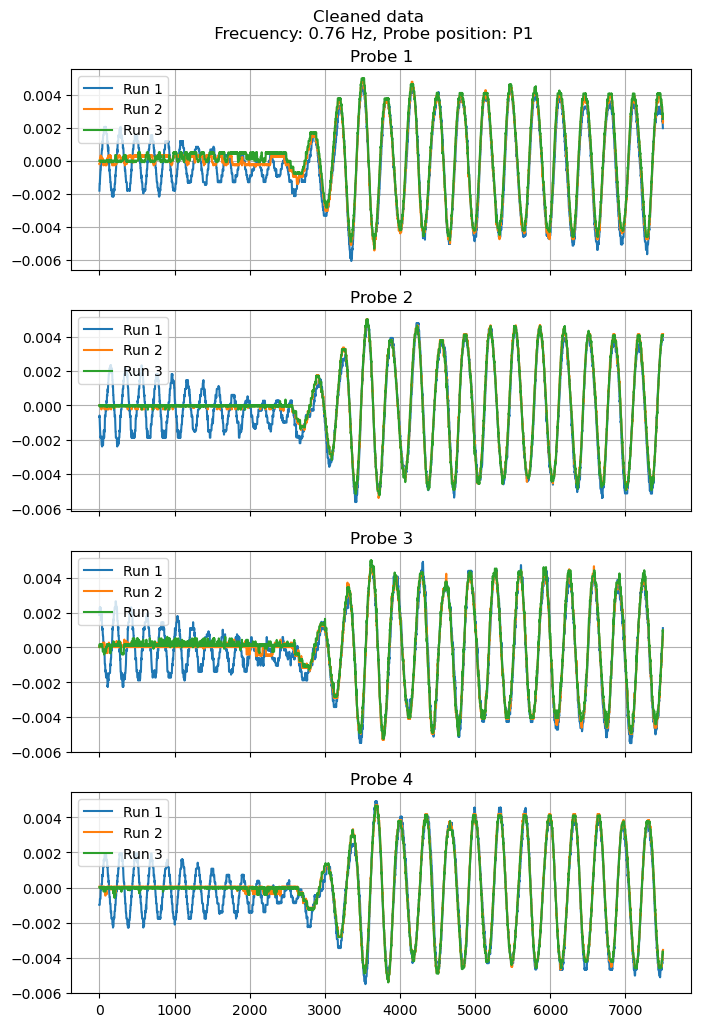

In [43]:
fig, ax = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

ax[0].plot(run1['p1'], label='Run 1')
ax[0].plot(run2['p1'], label='Run 2')
ax[0].plot(run3['p1'], label='Run 3')
ax[0].set_title('Probe 1')

ax[1].plot(run1['p2'], label='Run 1')
ax[1].plot(run2['p2'], label='Run 2')
ax[1].plot(run3['p2'], label='Run 3')
ax[1].set_title('Probe 2')

ax[2].plot(run1['p3'], label='Run 1')
ax[2].plot(run2['p3'], label='Run 2')
ax[2].plot(run3['p3'], label='Run 3')
ax[2].set_title('Probe 3')

ax[3].plot(run1['p4'], label='Run 1')
ax[3].plot(run2['p4'], label='Run 2')
ax[3].plot(run3['p4'], label='Run 3')
ax[3].set_title('Probe 4')

for axs in ax:
    axs.legend(loc='upper left')
    axs.grid()

fig.suptitle(f'Cleaned data \n Frecuency: {f} Hz, Probe position: {pos}', y=0.93)

In [44]:
# Applying low pass filter in the same style as Maxime
weights = np.array([0.1, 0.2, 0.4, 0.2, 0.1])

def processing(df, tol=1e-6, max_gap=4, passes=2):
    ''' 
    Corrects for large outliers and smoothes the data
    '''
    df_smooth = df.copy()

    for col in df_smooth.columns[1:5]:
        values = df_smooth[col].values.astype(float).copy()

        n = len(values)
        for gap in range(1, max_gap + 1):
            for i in range(1, n - gap - 1):
                left = values[i - 1]
                right = values[i + gap]
                if abs(left - right) < tol:
                    middle = values[i:i + gap]
                    if all(abs(m - left) > tol for m in middle):
                        values[i:i + gap] = left

        for _ in range(passes):
            smoothed = values.copy()
            for i in range(2, len(values) - 2):
                window = values[i-2:i+3]
                smoothed[i] = np.dot(weights, window)
            values = smoothed

        df_smooth[col] = values
    
    return df_smooth

In [45]:
# Processed data
run1_p = processing(run1)
run2_p = processing(run2)
run3_p = processing(run3)

Text(0.5, 0.93, 'Filtered data \n Frecuency: 0.76 Hz, Probe position: P1')

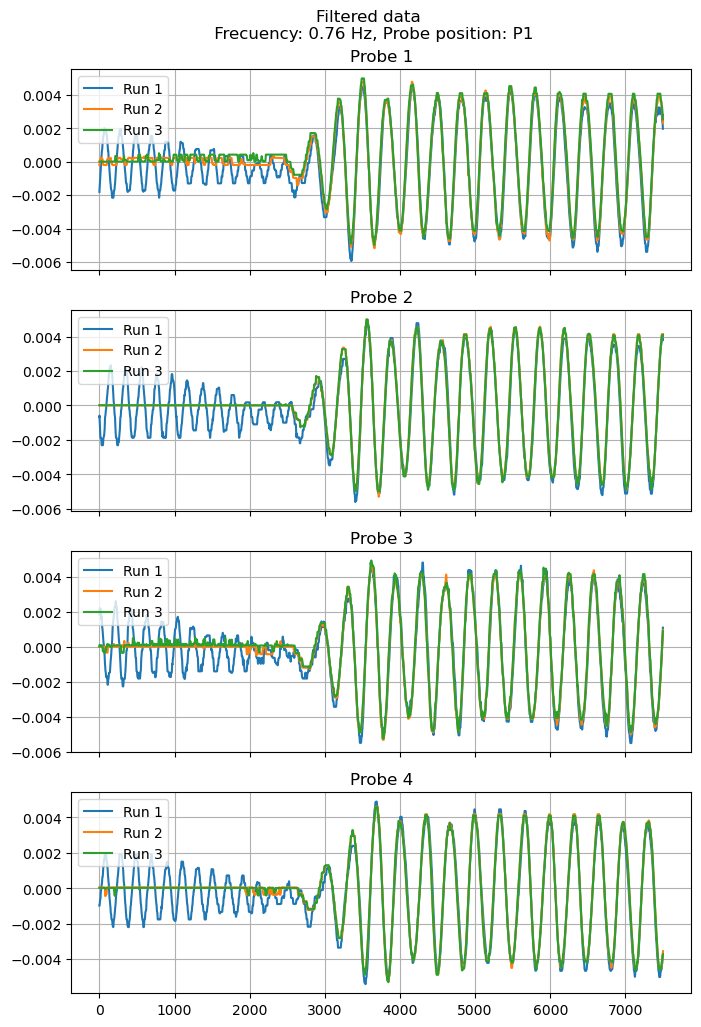

In [46]:
fig, ax = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

ax[0].plot(run1_p['p1'], label='Run 1')
ax[0].plot(run2_p['p1'], label='Run 2')
ax[0].plot(run3_p['p1'], label='Run 3')
ax[0].set_title('Probe 1')

ax[1].plot(run1_p['p2'], label='Run 1')
ax[1].plot(run2_p['p2'], label='Run 2')
ax[1].plot(run3_p['p2'], label='Run 3')
ax[1].set_title('Probe 2')

ax[2].plot(run1_p['p3'], label='Run 1')
ax[2].plot(run2_p['p3'], label='Run 2')
ax[2].plot(run3_p['p3'], label='Run 3')
ax[2].set_title('Probe 3')

ax[3].plot(run1_p['p4'], label='Run 1')
ax[3].plot(run2_p['p4'], label='Run 2')
ax[3].plot(run3_p['p4'], label='Run 3')
ax[3].set_title('Probe 4')

for axs in ax:
    axs.legend(loc='upper left')
    axs.grid()

fig.suptitle(f'Filtered data \n Frecuency: {f} Hz, Probe position: {pos}', y=0.93)

When the wave maker starts generating waves, it takes some time for the movement to become linear. As a first guess, I will focus on looking at the 10th wave, and hoping this is when the waves have "settled in". 

To do so, we need to find the row in the dataset where the 10th wave begins. That is, which row is where the 10th wave enters probe 1 at the given position. The time it takes for a given wave crest with a given speed to reach a given position.

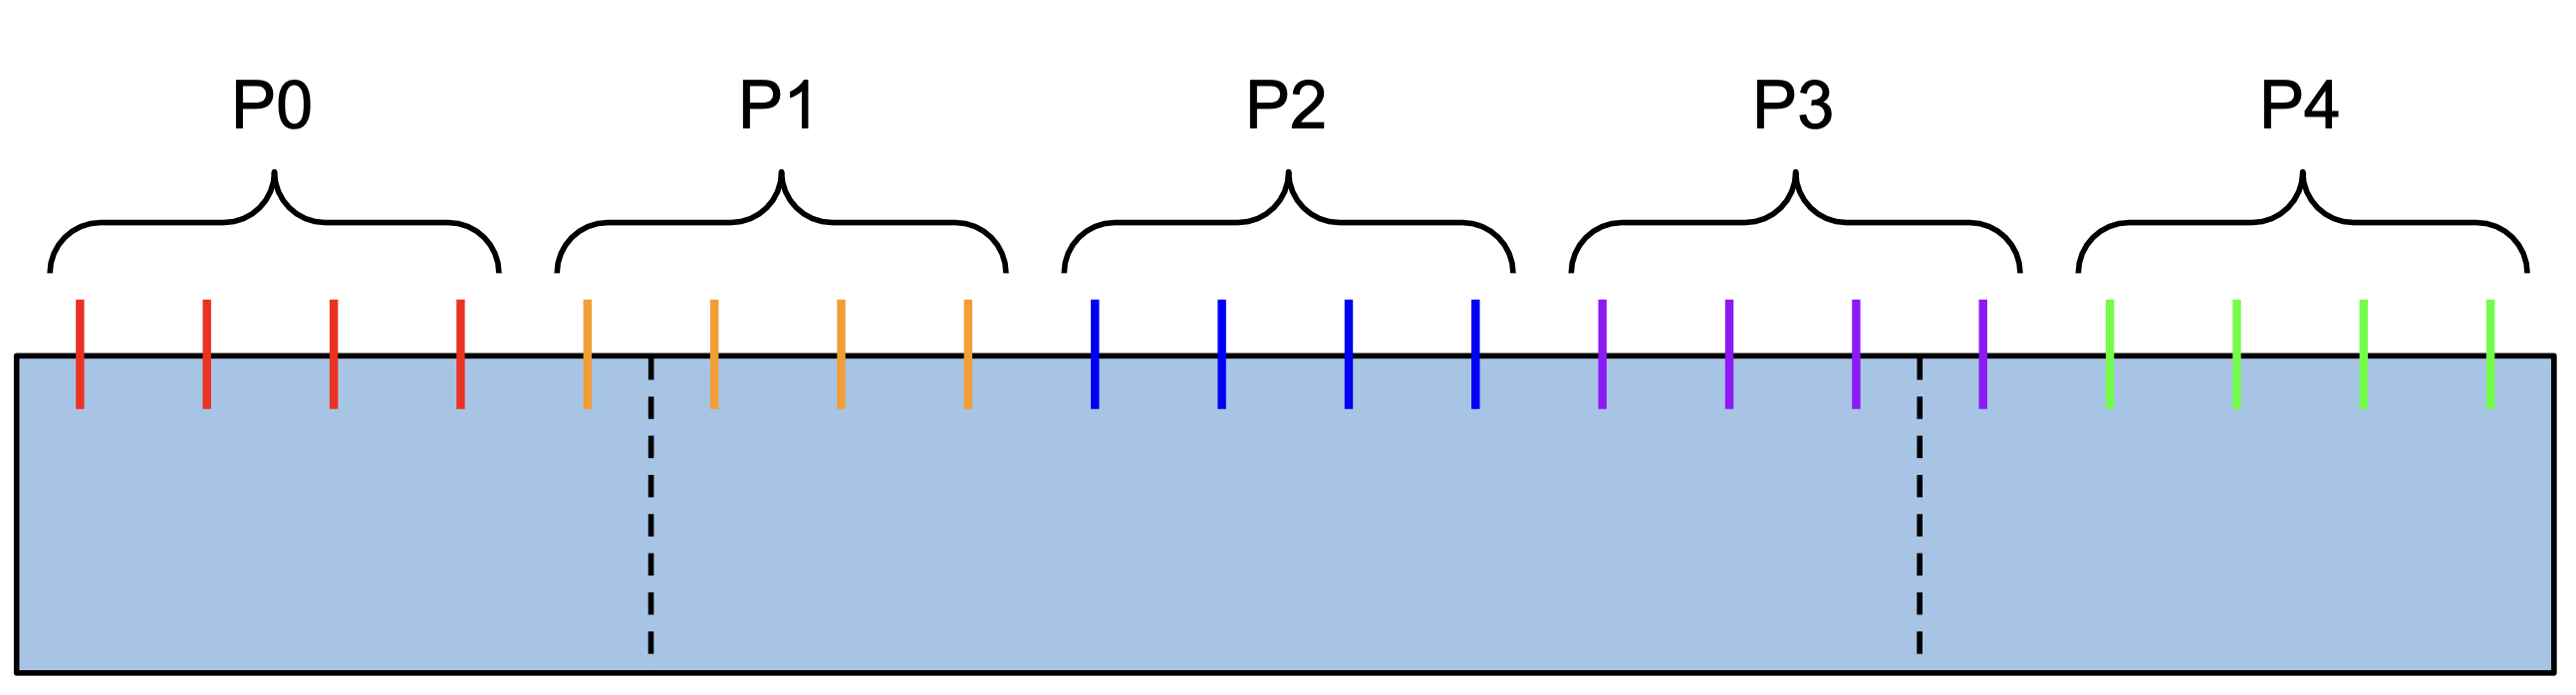

In [47]:
image_path = '/Users/kjesta/Desktop/Master prosjekt/Figurer/probe_positions.png'
display(Image(filename=image_path))

`X_base` is the positions of the four probes at location P0. Moving the rack to the left adds 1.215 m to each probe position.

In [48]:
X_base = np.array([11.075, 11.38, 11.685, 11.99])  # Base positions [m]
offset = 1.215

if pos == positions[0]:
    probe_positions = X_base

if pos == positions[1]:
    probe_positions = X_base + offset

if pos == positions[2]:
    probe_positions = X_base + offset*2

if pos == positions[3]:
    probe_positions = X_base + offset*3

if pos == positions[4]:
    probe_positions = X_base + offset*4

beach_start = 12.4
beach_end = 15.45

Function which estimates the wavelength and dominant frequency from the probe data

In [49]:
def estimate_wavelength(df, probe_positions):
    signals = [[],[],[],[]]  # for storing probe signals

    for i in range(1, 5):
        signals[i-1] = df.iloc[:, i].values
    
    signals = np.array(signals)
    n_probes = 4

    total_time = (df['time'].iloc[-1] - df['time'].iloc[0]).total_seconds()
    dt = total_time / len(df['time'])  # time step
    fs = 1 / dt  # sample frequency
    n = len(df['time'])
    
    # FFT of each signal
    fft_signals = fft(signals, axis=1)
    freqs = fftfreq(n, d=dt)
    
    # Keep only positive frequencies
    pos_freqs = freqs[:n//2]
    fft_pos = fft_signals[:, :n//2]

    
    # Find the dominant frequency (for example, on the signal of the 1st probe)
    power = np.abs(fft_pos[0])**2
    dominant_idx = np.argmax(power[1:]) + 1  # ignore DC (frequency 0)
    f_dom = pos_freqs[dominant_idx]
    omega_dom = 2 * np.pi * f_dom

    # Extract phases at this frequency for each probe
    phases = np.angle(fft_pos[:, dominant_idx])
    unwrapped_phases = np.unwrap(phases)

    # Linear fit: phase = k * x + phi0 → slope = k
    coeffs = np.polyfit(probe_positions, unwrapped_phases, 1)
    
    k = coeffs[0]  # wave number (rad/m)

    # Wavelength
    wavelength = 2 * np.pi / np.abs(k)
    
    return wavelength, f_dom

Based of the wavelength and frequency above, we can get the speed of the waves

In [50]:
def wavespeed(wavelength, f_dom):
    if wavelength is not None and wavelength != 0:
        k = 2 * np.pi / wavelength
        speed = (2 * np.pi * f_dom) / k
    else:
        speed = None
    
    return speed

Using the wave speed and the tank length we can figure out how many waves we can 'have' before reflections from the far end of the tank comes to play. 

In [51]:
def compute_max_wave_number(wavelength, tank_length=16.4):
    if wavelength is None or wavelength == 0:
        return None
    return int(tank_length / wavelength)

Now combining all these functions such that we can choose a clean wave to analyze.

In [52]:
def analyze_wave(df, probe_positions, tank_length=16.4, waves_to_take=1):
    wavelength, f_dom = estimate_wavelength(df, probe_positions)
    speed = wavespeed(wavelength, f_dom)
    n_max = compute_max_wave_number(wavelength, tank_length=tank_length)

    print(f"Dominant frequency: {f_dom:.4f} Hz")
    print(f"Wavelength: {wavelength:.4f} m")
    print(f"Phase speed: {speed:.4f} m/s")
    print(f"Max waves before reflection: {n_max}")

    dt = (df['time'].iloc[1] - df['time'].iloc[0]).total_seconds()
    T = 1 / f_dom  # period of dominant wave
    samples_per_wave = int(np.round(T / dt))
    
    first_wave = max(0, n_max - waves_to_take)
    last_wave = n_max

    start_idx = 3100 + first_wave * samples_per_wave
    end_idx = 3100 + last_wave * samples_per_wave

    base_wave_indices = np.arange(start_idx, end_idx)
    
    # Compute probe-specific wave indices
    ref_pos = probe_positions[0]
    probe_wave_indices = {}
    for i, pos in enumerate(probe_positions):
        delay_time = (pos - ref_pos) / speed       # seconds
        delay_samples = int(np.round(delay_time / dt))
        shifted_indices = base_wave_indices + delay_samples
        probe_wave_indices[f"p{i+1}"] = shifted_indices

    print(f"Analyzing wave indices (base): {start_idx} to {end_idx-1} (total {len(base_wave_indices)})")
    return wavelength, f_dom, speed, n_max, probe_wave_indices

In [53]:
wl_r1, f_dom_r1, speed_r1, n_max_r1, wave_indices_r1 = analyze_wave(run1_p, probe_positions)

Dominant frequency: 0.7669 Hz
Wavelength: 1.6636 m
Phase speed: 1.2758 m/s
Max waves before reflection: 9
Analyzing wave indices (base): 5708 to 6033 (total 326)


In [54]:
wl_r2, f_dom_r2, speed_r2, n_max_r2, wave_indices_r2 = analyze_wave(run2_p, probe_positions)

Dominant frequency: 0.7667 Hz
Wavelength: 1.6565 m
Phase speed: 1.2700 m/s
Max waves before reflection: 9
Analyzing wave indices (base): 5708 to 6033 (total 326)


In [55]:
wl_r3, f_dom_r3, speed_r3, n_max_r3, wave_indices_r3 = analyze_wave(run3_p, probe_positions)

Dominant frequency: 0.7669 Hz
Wavelength: 1.6578 m
Phase speed: 1.2713 m/s
Max waves before reflection: 9
Analyzing wave indices (base): 5708 to 6033 (total 326)


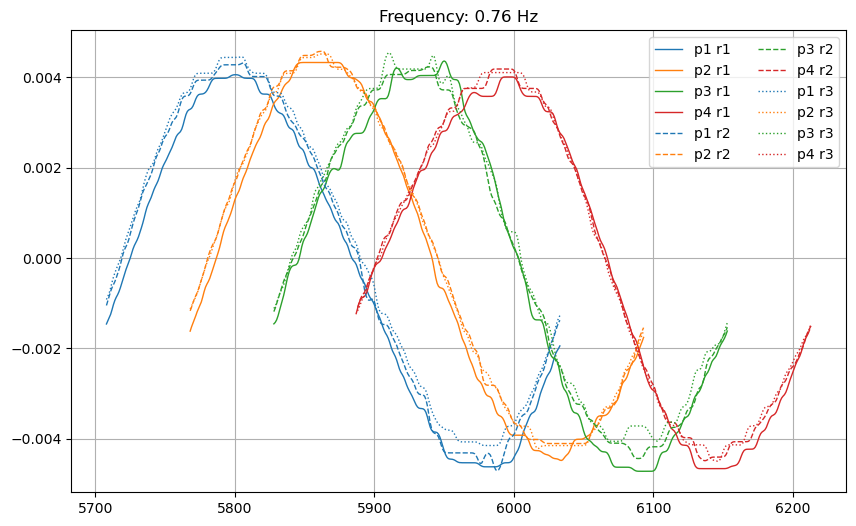

In [56]:
# Colors per probe
probe_colors = {
    'p1': 'tab:blue',
    'p2': 'tab:orange',
    'p3': 'tab:green',
    'p4': 'tab:red'
}

# Line styles per run
run_styles = {
    'r1': '-',
    'r2': '--',
    'r3': ':'
}

# Collect runs in a dict for easy looping
runs = {
    'r1': run1_p,
    'r2': run2_p,
    'r3': run3_p
}

plt.figure(figsize=(10, 6))

# Loop over runs and probes
for run_name, run_data in runs.items():
    wave_indices = globals()[f"wave_indices_{run_name}"]  # e.g. wave_indices_r1
    for probe in probe_colors.keys():
        idx = wave_indices[probe]  # probe-specific indices
        plt.plot(run_data[probe].iloc[idx],
                 color=probe_colors[probe],
                 linestyle=run_styles[run_name],
                 linewidth=1,
                 label=f"{probe} {run_name}")

plt.title(f'Frequency: {f:.2f} Hz')
plt.grid()
plt.legend(ncol=2)
plt.show()

In [57]:
def compute_stds(df, wave_indices):
    stds = []
    
    for probe_col, idx_list in wave_indices.items():
        std_col = df.loc[idx_list, probe_col].std()
        stds.append(std_col)
    
    return stds 

In [58]:
std_r1 = compute_stds(run1_p, wave_indices_r1)
std_r2 = compute_stds(run2_p, wave_indices_r2)
std_r3 = compute_stds(run3_p, wave_indices_r3)

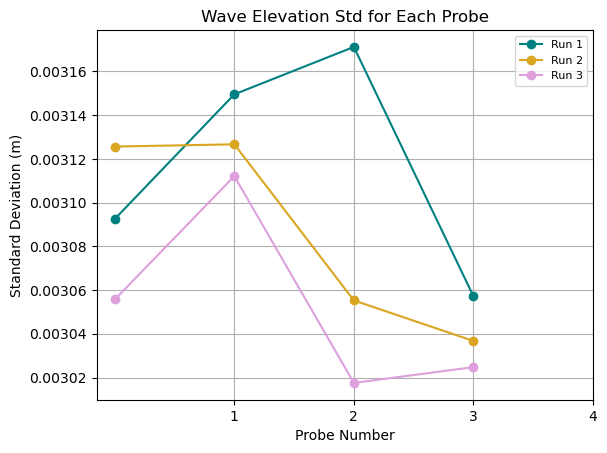

In [59]:
probes = [1, 2, 3, 4]

plt.plot(std_r1, marker='o', color='teal', label='Run 1')
plt.plot(std_r2, marker='o', color='goldenrod', label='Run 2')
plt.plot(std_r3, marker='o', color='plum', label='Run 3')

plt.xlabel('Probe Number')
plt.ylabel('Standard Deviation (m)')  # Adjust unit if needed
plt.title('Wave Elevation Std for Each Probe')
plt.xticks(probes)
plt.legend(fontsize=8)
plt.grid(True)

Viscous boundary layer height for oscillatory flow:

$$\delta= \sqrt{\frac{2 \nu}{2 \pi f}}$$

There will be a boundary layer on the sides of the plates, which is the reason for damping of the waves. The waves push water into the Hele-Shaw cells due to pressure, and inside the walls viscous forces will dampen it out. The larger the viscous boundary layer height, the more damping.

In [60]:
delta = np.sqrt((2*nu)/(2*np.pi*f))
print(f'{delta:.6f}')

0.002047
